<a href="https://colab.research.google.com/github/talhanoor23/ML-Algorithm-Implementation/blob/main/02-Logistic-Regression/Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Training a Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(solver='liblinear')

In [ ]:
%%time
model.fit(train_inputs[numeric_train_inputs + encoded_cols], train_outputs)
#we simply pick the numeric and encoded coulumn not categorical bcz categ.. are also present along with encoded

CPU times: user 2.01 s, sys: 174 ms, total: 2.18 s
Wall time: 2.86 s


LogisticRegression(solver='liblinear')

In [ ]:
print(numeric_train_inputs + encoded_cols)

['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Location_Adelaide', 'Location_Albany', 'Location_Albury', 'Location_AliceSprings', 'Location_BadgerysCreek', 'Location_Ballarat', 'Location_Bendigo', 'Location_Brisbane', 'Location_Cairns', 'Location_Canberra', 'Location_Cobar', 'Location_CoffsHarbour', 'Location_Dartmoor', 'Location_Darwin', 'Location_GoldCoast', 'Location_Hobart', 'Location_Katherine', 'Location_Launceston', 'Location_Melbourne', 'Location_MelbourneAirport', 'Location_Mildura', 'Location_Moree', 'Location_MountGambier', 'Location_MountGinini', 'Location_Newcastle', 'Location_Nhil', 'Location_NorahHead', 'Location_NorfolkIsland', 'Location_Nuriootpa', 'Location_PearceRAAF', 'Location_Penrith', 'Location_Perth', 'Location_PerthAirport', 'Location_Portland', 'Location_Richmond', 'Location_Sale', 'Location_

In [ ]:
print(model.coef_.tolist()) #weight

[[0.8986310435831582, -2.879914964510936, 3.16277770185562, 0.8542465101646303, -1.6713939517586038, 6.764401019680559, -0.942321727599129, -1.4284289075683034, 0.3228924332663022, 5.995315064220104, 5.463856765510025, -9.176804958768757, -0.16229709019708502, 1.2876596761585262, 0.47471524395691095, 2.021429503600586, 0.6016501640498816, -0.5524821074052095, 0.47814276613514417, 0.00766965564077951, 0.3468145228050993, -0.35227720511882743, 0.17971069430916792, 0.44048641115129067, -0.013981766534315494, 0.028943854443275466, 0.2581473851341608, -0.021205522156638217, -0.04279500597188526, -0.4831416876485812, -0.1375633111197264, -0.5760595598322682, -0.7875234368787923, -0.25540411019267395, -0.3288839108069863, -0.5690043941955333, 0.08183002285619907, 0.013382443311912332, 0.06412748497735833, -0.9020545503311315, -0.4443298408837363, 0.008517036245813925, -0.4606124008098094, -0.4655180699011165, -0.06949890538066067, 0.19115878962861627, 0.4504758434414625, 0.6081210644368628, 0

In [ ]:
weight_df = pd.DataFrame({
    'features': numeric_train_inputs + encoded_cols,
    'weight': model.coef_.tolist()[0] #it is 2-Dim array so we use 0
})

In [ ]:
weight_df

,features,weight
0,MinTemp,0.898631
1,MaxTemp,-2.879915
2,Rainfall,3.162778
3,Evaporation,0.854247
4,Sunshine,-1.671394
...,...,...
113,WindDir3pm_W,-0.180370
114,WindDir3pm_WNW,-0.033499
115,WindDir3pm_WSW,-0.275976
116,RainToday_No,-1.473517


<Axes: xlabel='weight', ylabel='features'>

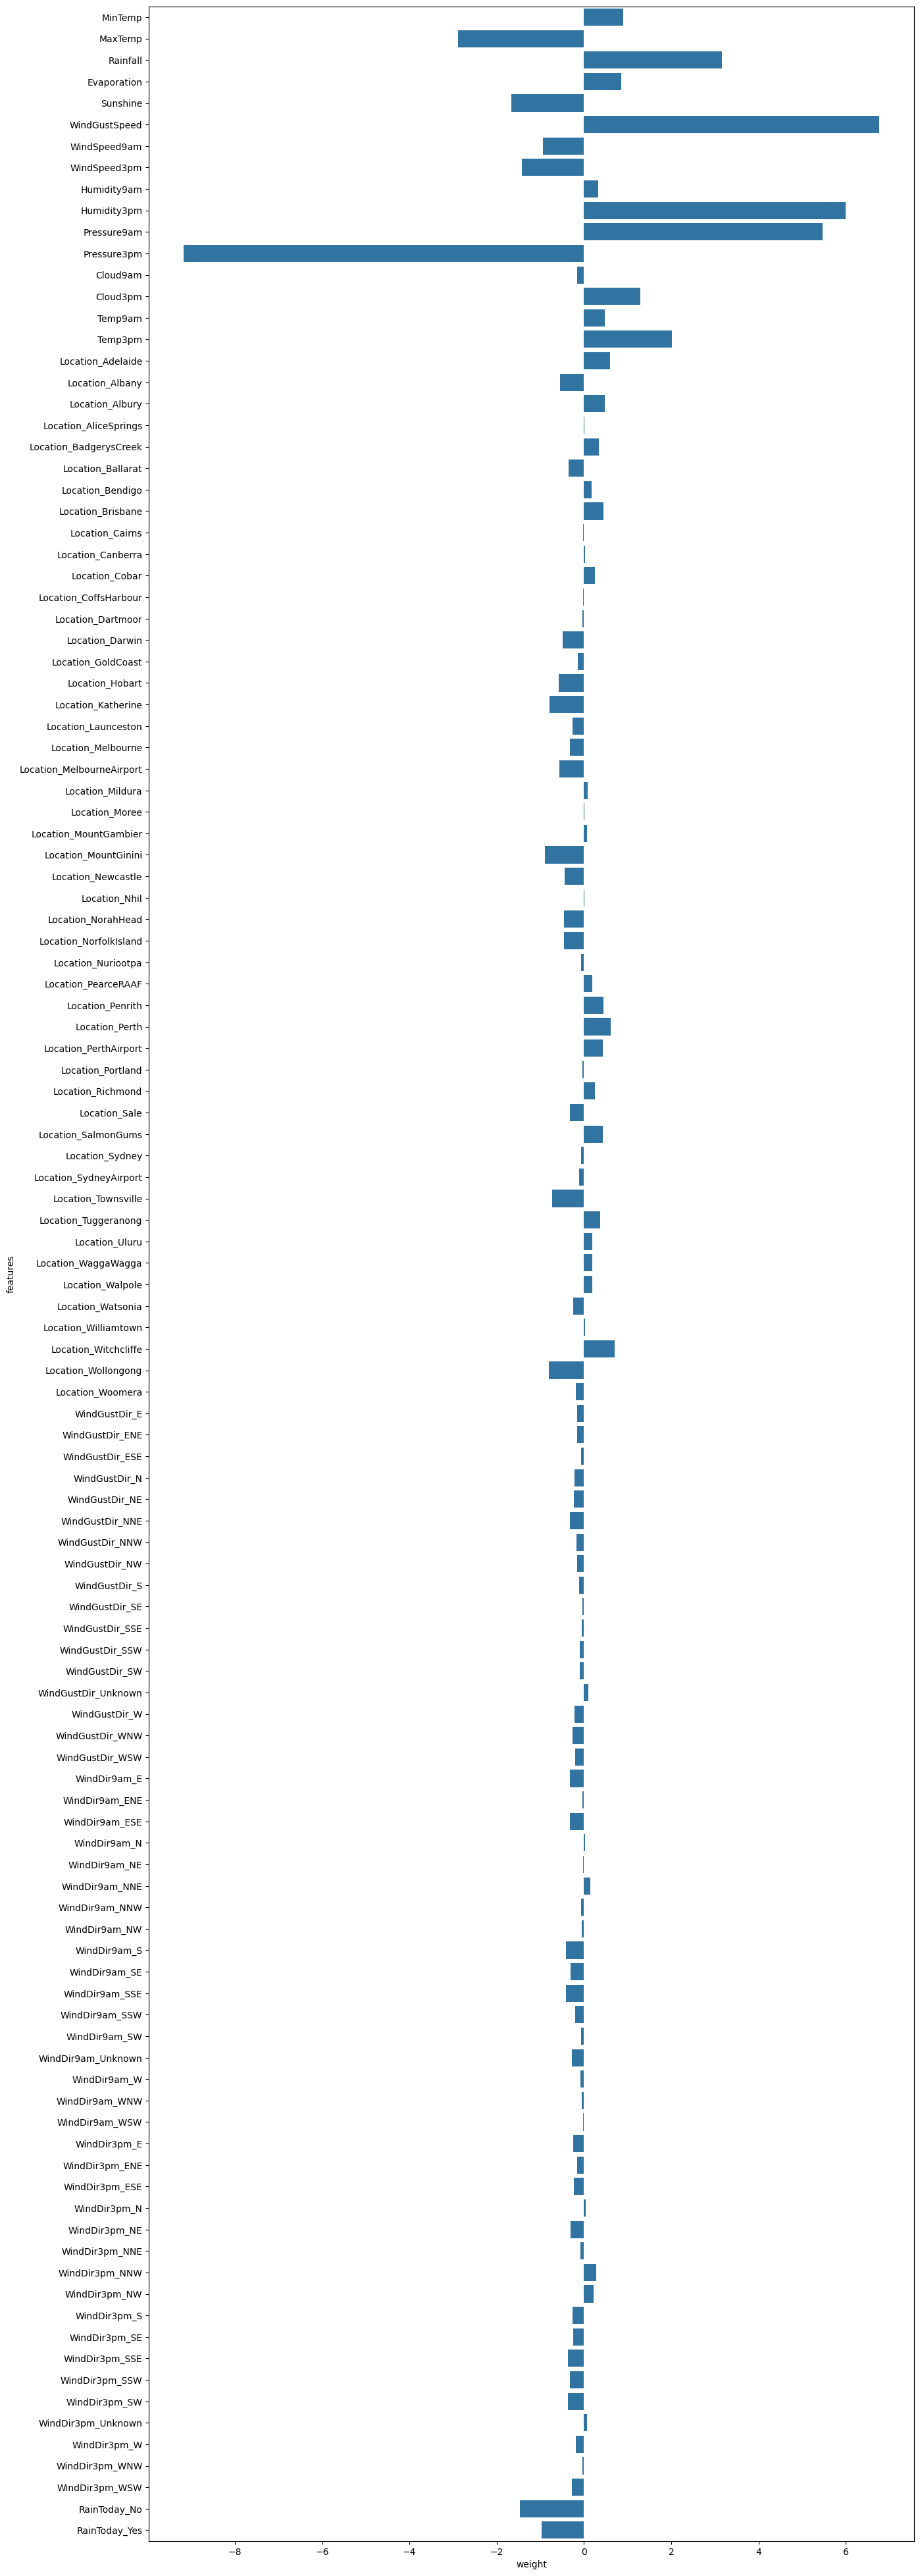

In [ ]:
plt.figure(figsize=(15, 50))
sns.barplot(data=weight_df, x='weight', y='features')

<Axes: xlabel='weight', ylabel='features'>

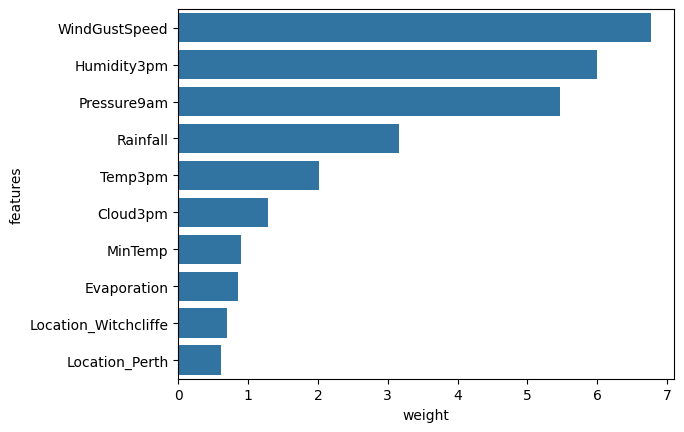

In [ ]:
sns.barplot(data=weight_df.sort_values('weight', ascending = False).head(10), x='weight', y='features')

In [ ]:
x_train = train_inputs[numeric_train_inputs + encoded_cols]
x_val = val_inputs[numeric_train_inputs + encoded_cols]
x_test = test_inputs[numeric_train_inputs + encoded_cols]

In [ ]:
train_preds = model.predict(x_train)

In [ ]:
#compare the data in beautiful way.
pd.DataFrame({
    'actual': train_outputs,
    'prediction': train_preds
})

,actual,prediction
0,No,No
1,No,No
2,No,No
3,No,No
4,No,No
...,...,...
144548,No,No
144549,No,No
144550,No,No
144551,No,No


# **Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(train_outputs, train_preds, normalize='true')

array([[0.94621341, 0.05378659],
       [0.4776585 , 0.5223415 ]])